# Localização com Fusão de Dados Sensoriais
Este notebook apresenta implementações de técnicas de fusão de dados sensoriais aplicadas a um modelo simplificado de robô móvel em um plano. Por meio dos códigos aqui disponibilizados, será possível observar como diferentes sensores podem ser combinados para melhorar a percepção do ambiente pelo robô e, consequentemente, sua capacidade de navegação.

# *Dead Reckoning*
As soluções baseadas em *dead reckoning* realizam a estimação da localização baseada na velocidade, direção e tempo a respeito da estimativa anterior. Após um determinado tempo, essa estimação se deteriora, pois o erro é somado a cada iteração. Nesse código é implementada uma solução de *dead reckoning* para um robô móvel se deslocando em um plano.

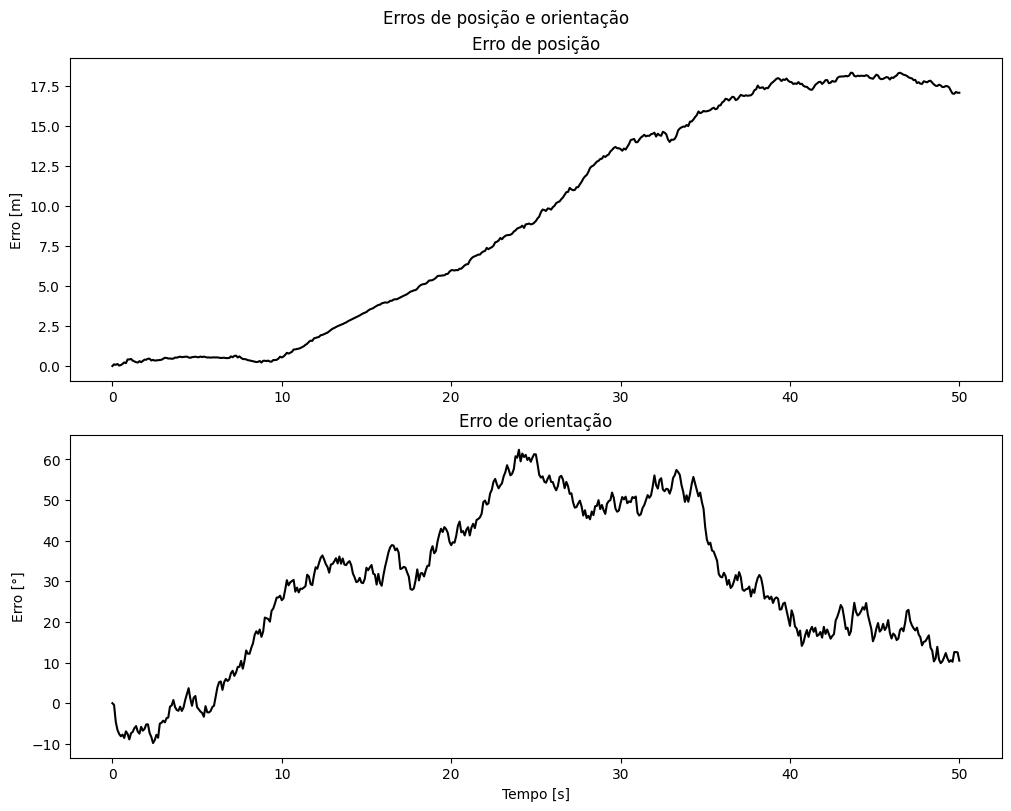

In [ ]:
import math
import numpy as np
from matplotlib import animation
import matplotlib.pyplot as plt
from IPython.display import HTML

# Parâmetros da simulação
DT = 0.1 # Período de atualização da simulação
SIM_T = 50 # Tempo total de simulação

# Parâmetros de visualização
SHOW_ANIMATION = True # Se True, cria uma animação da simulação
SHOW_ERROR_PLOTS = True # Se True, cria gráficos dos erros

def motion_model(x, u):
  """
  Função que calcula a movimentação do robô em um plano.
  Args:
    x: Estado do robô, composto pela posição nos eixos X e Y, a orientação e
    a intensidade da velocidade translacional.
    u: Entrada do robô, composta pelas velocidades translacional e rotacional
    geradas pelos atuadores.

  Returns:
    x: Estado do robô após uma iteração da simulação.
  """

  F = np.array([[1.0, 0, 0, 0],
                [0, 1.0, 0, 0],
                [0, 0, 1.0, 0],
                [0, 0, 0, 0]])

  B = np.array([[DT * math.cos(x[2, 0]), 0],
                [DT * math.sin(x[2, 0]), 0],
                [0.0, DT],
                [1.0, 0.0]])
  x = F @ x + B @ u
  return x

def dead_reckoning(xDR, u):
  """
  Função que calcula a solução de dead reckoning.
  Args:
    x: Estado estimado.
    u: Entrada do robô.

  Returns:
    xDR: Estado estimado após uma iteração da simulação.
    xDR: Entrada do robô com ruído.
  """

  # Considerando que as velocidades lidas pelos sensores proprioceptivos
  # possuem um ruído associado.
  uD = u + (np.diag([1.0, np.deg2rad(30.0)]) ** 2) @ np.random.randn(2, 1)
  xDR = motion_model(xDR, uD)

  return xDR, uDR

def create_animation():
  """
  Função que cria os elementos para a animação.
  """
  fig, ax = plt.subplots()
  lineTrue = plt.plot([], [], "-b")[0]
  lineDR = plt.plot([], [], "-k")[0]
  plt.grid(True)
  plt.xlabel("x[m]")
  plt.ylabel("y[m]")
  plt.xlim(-20, 25)
  plt.ylim(-20, 25)
  title = plt.title("Posição do robô")
  plt.legend(["Posição Verdadeira", "Dead Reckoning"])

  return fig, lineTrue, lineDR

def angles_difference(angle1, angle2):
  """
  Função que calcula a diferença entre dois ângulos.
  """
  a = angle1 - angle2
  a = (a + 180) % 360 - 180

  return a


# Início da simulação, que irá considerar o estado do robô sendo composto pela
# posição nos eixos X e Y, a orientação e a intensidade da velocidade translacional.

time = 0
xTrue = np.zeros((4, 1)) # Estado do robô verdadeiro
xDR = np.zeros((4, 1)) # Estado do robô estimado por dead reckoning

# Cria variáveis para armazenar um histórico para gerar a animação
if SHOW_ANIMATION or SHOW_ERROR_PLOTS:
  hxTrue = xTrue
  hxDR = xDR

while SIM_T >= time:
  time += DT
  u = np.array([[1], [0.1]]) # Velocidade translacional em m/s e rotacional em rad/s
  xTrue = motion_model(xTrue, u)

  # Dead Reckoning
  xDR, uDR = dead_reckoning(xDR, u)

  if SHOW_ANIMATION or SHOW_ERROR_PLOTS:
    hxTrue = np.hstack((hxTrue, xTrue))
    hxDR = np.hstack((hxDR, xDR))

if SHOW_ANIMATION:
  figure_animation, lineTrue, lineDR = create_animation()

  plt.close()
  def draw_frame(n):
    """
    Função que atualiza a animação.
    """
    lineTrue.set_xdata(hxTrue[0, :n])
    lineTrue.set_ydata(hxTrue[1, :n])
    lineDR.set_xdata(hxDR[0, :n])
    lineDR.set_ydata(hxDR[1, :n])
    return (lineTrue,lineDR)

  animation_DR = animation.FuncAnimation(figure_animation, draw_frame, frames=int(time/DT), interval=30, blit=True)
  HTML(animation_DR.to_html5_video())
  from matplotlib import rc
  rc('animation', html='html5')

if SHOW_ERROR_PLOTS:
  figure_errors, axs = plt.subplots(2, constrained_layout=True, figsize=(10, 8))
  figure_errors.suptitle('Erros de posição e orientação')
  position_error = np.linalg.norm(hxDR[0:2, :] - hxTrue[0:2, :], 2, axis = 0)
  orientation_error = np.rad2deg(angles_difference(hxDR[2, :],hxTrue[2, :]))
  axs[0].set_title('Erro de posição')
  axs[1].set_title('Erro de orientação')
  axs[1].set_xlabel('Tempo [s]')
  axs[0].set_ylabel('Erro [m]')
  axs[1].set_ylabel('Erro [°]')
  axs[0].plot(np.linspace(0,time,position_error.size), position_error, '-k')
  axs[1].plot(np.linspace(0,time,orientation_error.size), orientation_error, '-k')



In [ ]:
animation_DR

# Extended Kalman Filter
 O Filtro Estendido de Kalman, ou *Extended Kalman Filter* (EKF), é um algoritmo recursivo que fornece estimativas para medidas com incertezas de sistemas não-lineares, com distribuições de probabilidade gaussianas. Nesse código, o EKF corrige as medidas obtidas de soluções de *dead reckoning* com medidas do GPS já transformadas em posição no sistema inercial local.

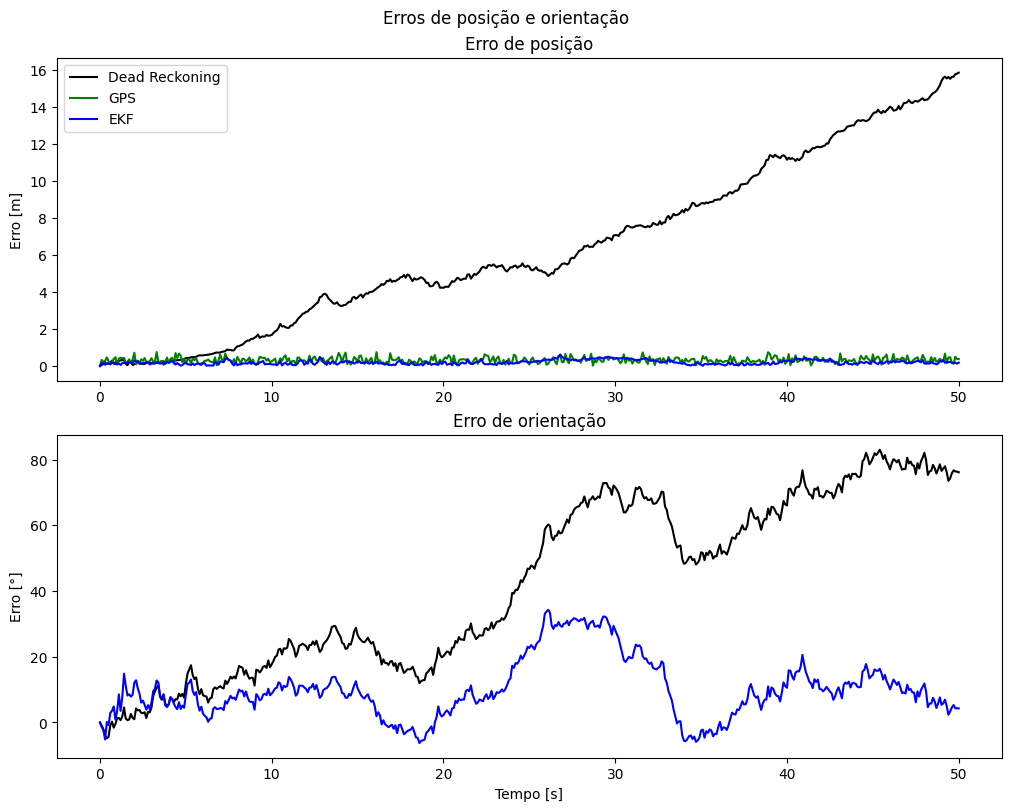

In [ ]:
import math
import numpy as np
from matplotlib import animation
import matplotlib.pyplot as plt
from IPython.display import HTML

# Parâmetros da simulação
DT = 0.1 # Período de atualização da simulação
SIM_T = 50 # Tempo total de simulação

# Parâmetros de visualização
SHOW_ANIMATION = True # Se True, cria uma animação da simulação
SHOW_ERROR_PLOTS = True # Se True, cria gráficos dos erros

# Parâmetros do EKF
Q = np.diag([
    0.1,  # variância da posição no eixo X
    0.1,  # variância da posição no eixo Y
    np.deg2rad(1.0),  # variância da orientação
    1.0  # variância da intensidade da velocidade
]) ** 2  # covariâncias da predição
R = np.diag([1.0, 1.0]) ** 2  # Covariância das observações como posições nos eixos X e Y

def motion_model(x, u):
  """
  Função que calcula a movimentação do robô em um plano.
  Args:
    x: Estado do robô, composto pela posição nos eixos X e Y, a orientação e
    a intensidade da velocidade translacional.
    u: Entrada do robô, composta pelas velocidades translacional e rotacional
    geradas pelos atuadores.

  Returns:
    x: Estado do robô após uma iteração da simulação.
  """

  F = np.array([[1.0, 0, 0, 0],
                [0, 1.0, 0, 0],
                [0, 0, 1.0, 0],
                [0, 0, 0, 0]])

  B = np.array([[DT * math.cos(x[2, 0]), 0],
                [DT * math.sin(x[2, 0]), 0],
                [0.0, DT],
                [1.0, 0.0]])
  x = F @ x + B @ u
  return x

def dead_reckoning(xDR, u):
  """
  Função que calcula a solução de dead reckoning.
  Args:
    x: Estado estimado.
    u: Entrada do robô.

  Returns:
    xDR: Estado estimado após uma iteração da simulação.
    xDR: Entrada do robô com ruído.
  """

  # Considerando que as velocidades lidas pelos sensores proprioceptivos
  # possuem um ruído associado.
  uDR = u + (np.diag([1.0, np.deg2rad(30.0)]) ** 2) @ np.random.randn(2, 1)
  xDR = motion_model(xDR, uDR)

  return xDR, uDR

def gps_data(xTrue):
  """
  Função que gera os dados do GPS.
  """
  z = observation_model(xTrue) + np.diag([0.5, 0.5]) ** 2 @ np.random.randn(2, 1)
  return z


def observation_model(x):
    """
    Função que calcula os valores do GPS a partir do estado do robô.
    """
    H = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    z = H @ x

    return z

def jacob_f(x, u):
    """
    Função que define o Jacobiano do modelo de movimentação
    """
    yaw = x[2, 0]
    v = u[0, 0]
    jF = np.array([
        [1.0, 0.0, -DT * v * math.sin(yaw), DT * math.cos(yaw)],
        [0.0, 1.0, DT * v * math.cos(yaw), DT * math.sin(yaw)],
        [0.0, 0.0, 1.0, 0.0],
        [0.0, 0.0, 0.0, 1.0]])

    return jF


def jacob_h():
    """
    Função que define o Jacobiano do modelo de observação
    """
    jH = np.array([
        [1, 0, 0, 0],
        [0, 1, 0, 0]
    ])

    return jH


def ekf_estimation(xEst, PEst, z, u):
    """
    Função que calcula a estimativa do estado do robô usando o EKF.
    """
    # Predição
    xPred = motion_model(xEst, u)
    jF = jacob_f(xEst, u)
    PPred = jF @ PEst @ jF.T + Q

    # Atualização
    jH = jacob_h()
    zPred = observation_model(xPred)
    y = z - zPred
    S = jH @ PPred @ jH.T + R
    K = PPred @ jH.T @ np.linalg.inv(S)
    xEst = xPred + K @ y
    PEst = (np.eye(len(xEst)) - K @ jH) @ PPred
    return xEst, PEst

def create_animation():
  """
  Função que cria os elementos para a animação.
  """
  fig, ax = plt.subplots()
  lineTrue = plt.plot([], [], "-b")[0]
  lineDR = plt.plot([], [], "-k")[0]
  lineGPS = plt.plot([], [], ".g")[0]
  lineEst = plt.plot([], [], "-r")[0]
  plt.grid(True)
  plt.xlabel("x[m]")
  plt.ylabel("y[m]")
  plt.xlim(-20, 25)
  plt.ylim(-20, 25)
  title = plt.title("Posição do robô")
  plt.legend(["Posição Verdadeira", "Dead Reckoning", "GPS", "EKF"])

  return fig, ax, lineTrue, lineDR, lineGPS, lineEst

def angles_difference(angle1, angle2):
  """
  Função que calcula a diferença entre dois ângulos.
  """
  a = angle1 - angle2
  a = (a + 180) % 360 - 180

  return a


# Início da simulação, que irá considerar o estado do robô sendo composto pela
# posição nos eixos X e Y, a orientação e a intensidade da velocidade translacional.

time = 0
xTrue = np.zeros((4, 1)) # Estado do robô verdadeiro
xDR = np.zeros((4, 1)) # Estado do robô estimado por dead reckoning
xGPS = np.zeros((2, 1)) # Posição no eixo X e Y medidos pelo GPS
xEst = np.zeros((4, 1)) # Estado estimado do robô
PEst = np.eye(4) # Covariância do estado estimado

# Cria variáveis para armazenar um histórico para gerar a animação
if SHOW_ANIMATION or SHOW_ERROR_PLOTS:
  hxTrue = xTrue
  hxDR = xDR
  hxGPS = xGPS
  hxEst = xEst
  hPEst = PEst


while SIM_T >= time:
  time += DT
  u = np.array([[1], [0.1]]) # Velocidade translacional em m/s e rotacional em rad/s
  xTrue = motion_model(xTrue, u)
  xGPS = gps_data(xTrue)

  # Dead Reckoning
  xDR, uDR = dead_reckoning(xDR, u)

  # EKF
  xEst, PEst = ekf_estimation(xEst, PEst, xGPS, uDR)

  if SHOW_ANIMATION or SHOW_ERROR_PLOTS:
    hxTrue = np.hstack((hxTrue, xTrue))
    hxDR = np.hstack((hxDR, xDR))
    hxGPS = np.hstack((hxGPS, xGPS))
    hxEst = np.hstack((hxEst, xEst))
    hPEst = np.dstack((hPEst, PEst))

if SHOW_ANIMATION:
  figure_animation, ax_animation, lineTrue, lineDR, lineGPS, lineEst = create_animation()

  plt.close()
  def draw_frame(n):
    """
    Função que atualiza a animação.
    """
    lineTrue.set_xdata(hxTrue[0, :n])
    lineTrue.set_ydata(hxTrue[1, :n])
    lineDR.set_xdata(hxDR[0, :n])
    lineDR.set_ydata(hxDR[1, :n])
    lineGPS.set_xdata(hxGPS[0, :n])
    lineGPS.set_ydata(hxGPS[1, :n])
    lineEst.set_xdata(hxEst[0, :n])
    lineEst.set_ydata(hxEst[1, :n])
    return (lineTrue,lineDR,lineGPS,lineEst)

  animation_EKF = animation.FuncAnimation(figure_animation, draw_frame, frames=int(time/DT), interval=30, blit=True)
  HTML(animation_EKF.to_html5_video())
  from matplotlib import rc
  rc('animation', html='html5')

if SHOW_ERROR_PLOTS:
  figure_errors, axs = plt.subplots(2, constrained_layout=True, figsize=(10, 8))
  figure_errors.suptitle('Erros de posição e orientação')
  position_error_DR = np.linalg.norm(hxDR[0:2, :] - hxTrue[0:2, :], 2, axis = 0)
  orientation_error_DR = np.rad2deg(angles_difference(hxDR[2, :],hxTrue[2, :]))
  position_error_GPS = np.linalg.norm(hxGPS[0:2, :] - hxTrue[0:2, :], 2, axis = 0)
  position_error_Est = np.linalg.norm(hxEst[0:2, :] - hxTrue[0:2, :], 2, axis = 0)
  orientation_error_Est = np.rad2deg(angles_difference(hxEst[2, :],hxTrue[2, :]))
  axs[0].set_title('Erro de posição')
  axs[1].set_title('Erro de orientação')
  axs[1].set_xlabel('Tempo [s]')
  axs[0].set_ylabel('Erro [m]')
  axs[1].set_ylabel('Erro [°]')
  axs[0].plot(np.linspace(0,time,position_error_DR.size), position_error_DR, '-k')
  axs[1].plot(np.linspace(0,time,orientation_error_DR.size), orientation_error_DR, '-k')
  axs[0].plot(np.linspace(0,time,position_error_GPS.size), position_error_GPS, '-g')
  axs[0].plot(np.linspace(0,time,position_error_Est.size), position_error_Est, '-b')
  axs[1].plot(np.linspace(0,time,orientation_error_Est.size), orientation_error_Est, '-b')
  axs[0].legend(["Dead Reckoning", "GPS", "EKF"])


In [ ]:
animation_EKF

# Filtro de Partículas
O Filtro de Partículas é um algoritmo recursivo que fornece estimativas para medidas com incertezas de sistemas não-lineares, para quaisquer distribuições de probabilidade. Isso é possível pois a distribuição é representada por um conjunto de partículas, cujas distribuições são atualizadas durante a execução do algoritmo. Nesse código, o Filtro de Partículas corrige as medidas obtidas de soluções de *dead reckoning* com medidas de distâncias relativas até objetos com posições conhecidas.

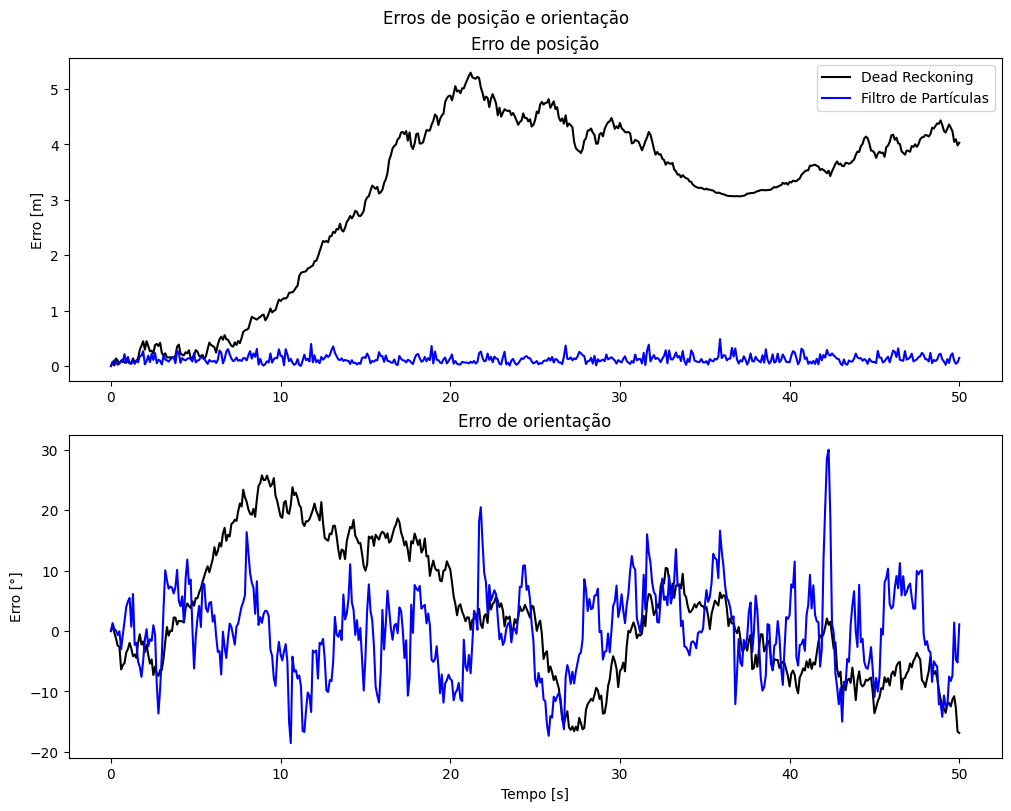

In [ ]:
import math
import numpy as np
from matplotlib import animation
import matplotlib.pyplot as plt
from IPython.display import HTML

# Parâmetros da simulação
DT = 0.1 # Período de atualização da simulação
SIM_T = 50 # Tempo total de simulação
MAX_RANGE = 20.0 # Alcance máximo para medições de distâncias relativas

# Parâmetros de visualização
SHOW_ANIMATION = True # Se True, cria uma animação da simulação
SHOW_ERROR_PLOTS = True # Se True, cria gráficos dos erros

# Parâmetros do Filtro de Partículas
Q = np.diag([0.2]) ** 2  # Erro das medições de distâncias relativas
R = np.diag([2.0, np.deg2rad(40.0)]) ** 2  # Erro das medições da entrada do robô
NP = 100 # Número de partículas
NTh = NP / 2.0 # Número de partículas para reamostragem

def motion_model(x, u):
  """
  Função que calcula a movimentação do robô em um plano.
  Args:
    x: Estado do robô, composto pela posição nos eixos X e Y, a orientação e
    a intensidade da velocidade translacional.
    u: Entrada do robô, composta pelas velocidades translacional e rotacional
    geradas pelos atuadores.

  Returns:
    x: Estado do robô após uma iteração da simulação.
  """

  F = np.array([[1.0, 0, 0, 0],
                [0, 1.0, 0, 0],
                [0, 0, 1.0, 0],
                [0, 0, 0, 0]])

  B = np.array([[DT * math.cos(x[2, 0]), 0],
                [DT * math.sin(x[2, 0]), 0],
                [0.0, DT],
                [1.0, 0.0]])
  x = F @ x + B @ u
  return x

def dead_reckoning(xDR, u):
  """
  Função que calcula a solução de dead reckoning.
  Args:
    x: Estado estimado.
    u: Entrada do robô.

  Returns:
    xDR: Estado estimado após uma iteração da simulação.
    xDR: Entrada do robô com ruído.
  """

  # Considerando que as velocidades lidas pelos sensores proprioceptivos
  # possuem um ruído associado.
  uDR = u + (np.diag([1.0, np.deg2rad(30.0)]) ** 2) @ np.random.randn(2, 1)
  xDR = motion_model(xDR, uDR)

  return xDR, uDR

def range_data(xTrue, landmarks):
  """
  Função que gera os dados de distâncias relativas.
  """
  z = np.zeros((0, 3))

  for i in range(len(landmarks[:, 0])):
    dx = xTrue[0, 0] - landmarks[i, 0]
    dy = xTrue[1, 0] - landmarks[i, 1]
    d = math.hypot(dx, dy)
    if d <= MAX_RANGE:
      dn = d + np.random.randn() * (0.2 ** 2) ** 0.5  # Adição do ruído
      zi = np.array([[dn, landmarks[i, 0], landmarks[i, 1]]])
      z = np.vstack((z, zi))

  return z

def gauss_likelihood(x, sigma):
    """
    Função que calcula a função de densidade de probabilidade gaussiana para
    atualização dos pesos.
    """
    p = 1.0 / math.sqrt(2.0 * math.pi * sigma ** 2) * \
        math.exp(-x ** 2 / (2 * sigma ** 2))

    return p


def calc_covariance(x_est, px, pw):
    """
    Função que calcula a covariância para o conjunto de partículas.
    """
    cov = np.zeros((4, 4))
    n_particle = px.shape[1]
    for i in range(n_particle):
        dx = (px[:, i:i + 1] - x_est)
        cov += pw[0, i] * dx @ dx.T
    cov *= 1.0 / (1.0 - pw @ pw.T)

    return cov


def pf_estimation(px, pw, z, u):
    """
    Função que calcula a estimativa do estado do robô usando o Filtro de Partículas.
    """
    for ip in range(NP):
        x = np.array([px[:, ip]]).T
        w = pw[0, ip]

        # Predição com ruído acrescentado para cada partícula
        ud1 = u[0, 0] + np.random.randn() * R[0, 0] ** 0.5
        ud2 = u[1, 0] + np.random.randn() * R[1, 1] ** 0.5
        ud = np.array([[ud1, ud2]]).T
        x = motion_model(x, ud)

        # Cálculo dos pesos de cada partícula
        for i in range(len(z[:, 0])):
            dx = x[0, 0] - z[i, 1]
            dy = x[1, 0] - z[i, 2]
            pre_z = math.hypot(dx, dy)
            dz = pre_z - z[i, 0]
            w = w * gauss_likelihood(dz, math.sqrt(Q[0, 0]))

        px[:, ip] = x[:, 0]
        pw[0, ip] = w

    pw = pw / pw.sum()  # Normalização dos pesos

    x_est = px.dot(pw.T)
    p_est = calc_covariance(x_est, px, pw)

    # Reamostragem das partículas
    N_eff = 1.0 / (pw.dot(pw.T))[0, 0]  # Número efetivo de partículas
    if N_eff < NTh:
        px, pw = re_sampling(px, pw)

    return x_est, p_est, px, pw


def re_sampling(px, pw):
    """
    Reamostragem das partículas.
    """

    w_cum = np.cumsum(pw)
    base = np.arange(0.0, 1.0, 1 / NP)
    re_sample_id = base + np.random.uniform(0, 1 / NP)
    indexes = []
    ind = 0
    for ip in range(NP):
        while re_sample_id[ip] > w_cum[ind]:
            ind += 1
        indexes.append(ind)

    px = px[:, indexes]
    pw = np.zeros((1, NP)) + 1.0 / NP

    return px, pw

def create_animation(landmarks):
  """
  Função que cria os elementos para a animação.
  """
  fig, ax = plt.subplots()
  plt.plot(landmarks[:, 0], landmarks[:, 1], "*m")
  lineTrue = plt.plot([], [], "-b")[0]
  lineDR = plt.plot([], [], "-k")[0]
  lineEst = plt.plot([], [], "-r")[0]
  linesRange = [plt.plot([], [], linestyle='dashed', color='black')[0] for _ in range(len(landmarks[:, 0]))]
  plt.grid(True)
  plt.xlabel("x[m]")
  plt.ylabel("y[m]")
  plt.xlim(-20, 25)
  plt.ylim(-20, 25)
  title = plt.title("Posição do robô")
  plt.legend(["Landmarks","Posição Verdadeira", "Dead Reckoning", "Filtro de Partículas"])

  return fig, ax, lineTrue, lineDR, lineEst, linesRange

def angles_difference(angle1, angle2):
  """
  Função que calcula a diferença entre dois ângulos.
  """
  a = angle1 - angle2
  a = (a + 180) % 360 - 180

  return a


# Início da simulação, que irá considerar o estado do robô sendo composto pela
# posição nos eixos X e Y, a orientação e a intensidade da velocidade translacional.

time = 0
xTrue = np.zeros((4, 1)) # Estado do robô verdadeiro
xDR = np.zeros((4, 1)) # Estado do robô estimado por dead reckoning
# xRange = np.zeros((4, 1)) # Distâncias relativas
xEst = np.zeros((4, 1)) # Estado estimado do robô
PEst = np.eye(4) # Covariância do estado estimado

# Cria variáveis para armazenar um histórico para gerar a animação
if SHOW_ANIMATION or SHOW_ERROR_PLOTS:
  hxTrue = xTrue
  hxDR = xDR
  hxRange = []
  hxEst = xEst
  hPEst = PEst

# Posições dos objetos conhecidos (landmarks)
landmarks = np.array([[10.0, 0.0],
                      [10.0, 10.0],
                      [0.0, 15.0],
                      [-5.0, 20.0]])

# Informações do conjunto de partículas
px = np.zeros((4, NP))  # Partículas
pw = np.zeros((1, NP)) + 1.0 / NP  # Pesos das partículas

while SIM_T >= time:
  time += DT
  u = np.array([[1], [0.1]]) # Velocidade translacional em m/s e rotacional em rad/s
  xTrue = motion_model(xTrue, u)
  xRange = range_data(xTrue, landmarks)

  # Dead Reckoning
  xDR, uDR = dead_reckoning(xDR, u)

  # Filtro de Partículas
  xEst, PEst, px, pw = pf_estimation(px, pw, xRange, uDR)

  if SHOW_ANIMATION or SHOW_ERROR_PLOTS:
    hxTrue = np.hstack((hxTrue, xTrue))
    hxDR = np.hstack((hxDR, xDR))
    hxRange.append(xRange)
    hxEst = np.hstack((hxEst, xEst))
    hPEst = np.dstack((hPEst, PEst))

if SHOW_ANIMATION:
  figure_animation, ax_animation, lineTrue, lineDR, lineEst, linesRange = create_animation(landmarks)

  plt.close()
  def draw_frame(n):
    """
    Função que atualiza a animação.
    """
    lineTrue.set_xdata(hxTrue[0, :n])
    lineTrue.set_ydata(hxTrue[1, :n])
    lineDR.set_xdata(hxDR[0, :n])
    lineDR.set_ydata(hxDR[1, :n])
    for i in range(len(linesRange)):
      linesRange[i].set_xdata([])
      linesRange[i].set_ydata([])
    for i in range(len(hxRange[n])):
      linesRange[i].set_xdata([hxTrue[0, n], hxRange[n][i][1]])
      linesRange[i].set_ydata([hxTrue[1, n], hxRange[n][i][2]])
    lineEst.set_xdata(hxEst[0, :n])
    lineEst.set_ydata(hxEst[1, :n])
    return (lineTrue,lineDR,lineEst)

  animation_PF = animation.FuncAnimation(figure_animation, draw_frame, frames=int(time/DT), interval=30, blit=False)
  HTML(animation_PF.to_html5_video())
  from matplotlib import rc
  rc('animation', html='html5')

if SHOW_ERROR_PLOTS:
  figure_errors, axs = plt.subplots(2, constrained_layout=True, figsize=(10, 8))
  figure_errors.suptitle('Erros de posição e orientação')
  position_error_DR = np.linalg.norm(hxDR[0:2, :] - hxTrue[0:2, :], 2, axis = 0)
  orientation_error_DR = np.rad2deg(angles_difference(hxDR[2, :],hxTrue[2, :]))
  position_error_Est = np.linalg.norm(hxEst[0:2, :] - hxTrue[0:2, :], 2, axis = 0)
  orientation_error_Est = np.rad2deg(angles_difference(hxEst[2, :],hxTrue[2, :]))
  axs[0].set_title('Erro de posição')
  axs[1].set_title('Erro de orientação')
  axs[1].set_xlabel('Tempo [s]')
  axs[0].set_ylabel('Erro [m]')
  axs[1].set_ylabel('Erro [°]')
  axs[0].plot(np.linspace(0,time,position_error_DR.size), position_error_DR, '-k')
  axs[1].plot(np.linspace(0,time,orientation_error_DR.size), orientation_error_DR, '-k')
  axs[0].plot(np.linspace(0,time,position_error_Est.size), position_error_Est, '-b')
  axs[1].plot(np.linspace(0,time,orientation_error_Est.size), orientation_error_Est, '-b')
  axs[0].legend(["Dead Reckoning", "Filtro de Partículas"])


In [ ]:
animation_PF



---

Os códigos foram construídos com o auxílio de códigos disponíveis no projeto Python Robotics, que pode ser acessado em https://github.com/AtsushiSakai/PythonRobotics  